In [8]:
from matplotlib import pyplot as plt
import pandas as pd
import netCDF4
import xarray as xr
import numpy as np

In [12]:
#open datset

ds80 = xr.open_dataset("woa23_decav_t07_01.nc", decode_times = False)
ds20 = xr.open_dataset('woa23_decav_t04_01 (1).nc', decode_times = False)
# print(dss.variables)

tdata = pd.read_excel('sediment pteropod 13C and 18O data copy.xlsx', sheet_name = 'tempworkup')


#index variables
t80 = ds80['t_an']
t20 = ds20['t_an']

datacsv = "Sediment_O18C13.csv"
tdata.to_csv(datacsv, index=False)
datacsv = pd.read_csv(datacsv)

noclean = datacsv[datacsv['Name of Test'].str.contains('No cleaning')]
sonic = datacsv[datacsv['Name of Test'].str.contains('Sonicate ')]
redsonic = datacsv[datacsv['Name of Test'].str.contains('Sonicate+red', regex=False)]
oxredsonic = datacsv[datacsv['Name of Test'].str.contains('Sonicate++red+ox', regex=False)]

nocleano = noclean['mean d18O (PDB)']
sonico = sonic['mean d18O (PDB)']
redsonico = redsonic['mean d18O (PDB)']
oxredsonico = oxredsonic['mean d18O (PDB)']

nocleanc = noclean['mean d13C (PDB)']
sonicc = sonic['mean d13C (PDB)']
redsonicc = redsonic['mean d13C (PDB)']
oxredsonicc = oxredsonic['mean d13C (PDB)']

nocleand = noclean['depth']
sonicd = sonic['depth']
redsonicd = redsonic['depth']
oxredsonicd = redsonic['depth']





Depth: 0.0 m → Temp: 22.27 °C
Depth: 5.0 m → Temp: 22.22 °C
Depth: 10.0 m → Temp: 22.17 °C
Depth: 15.0 m → Temp: 22.10 °C
Depth: 20.0 m → Temp: 22.02 °C
Depth: 25.0 m → Temp: 21.91 °C
Depth: 30.0 m → Temp: 21.79 °C
Depth: 35.0 m → Temp: 21.69 °C
Depth: 40.0 m → Temp: 21.54 °C
Depth: 45.0 m → Temp: 21.41 °C
Depth: 50.0 m → Temp: 21.28 °C
Depth: 55.0 m → Temp: 21.13 °C
Depth: 60.0 m → Temp: 20.97 °C
Depth: 65.0 m → Temp: 20.81 °C
Depth: 70.0 m → Temp: 20.67 °C
Depth: 75.0 m → Temp: 20.51 °C
Depth: 80.0 m → Temp: 20.34 °C
Depth: 85.0 m → Temp: 20.16 °C
Depth: 90.0 m → Temp: 20.01 °C
Depth: 95.0 m → Temp: 19.84 °C
Depth: 100.0 m → Temp: 19.69 °C
Depth: 125.0 m → Temp: 18.93 °C
Depth: 150.0 m → Temp: 18.01 °C
Depth: 175.0 m → Temp: 17.35 °C
Depth: 200.0 m → Temp: 16.66 °C
Depth: 225.0 m → Temp: 15.99 °C
Depth: 250.0 m → Temp: 15.38 °C
Depth: 275.0 m → Temp: 14.70 °C
Depth: 300.0 m → Temp: 14.09 °C
Depth: 325.0 m → Temp: 13.48 °C
Depth: 350.0 m → Temp: 12.89 °C
Depth: 375.0 m → Temp: 12.31 °

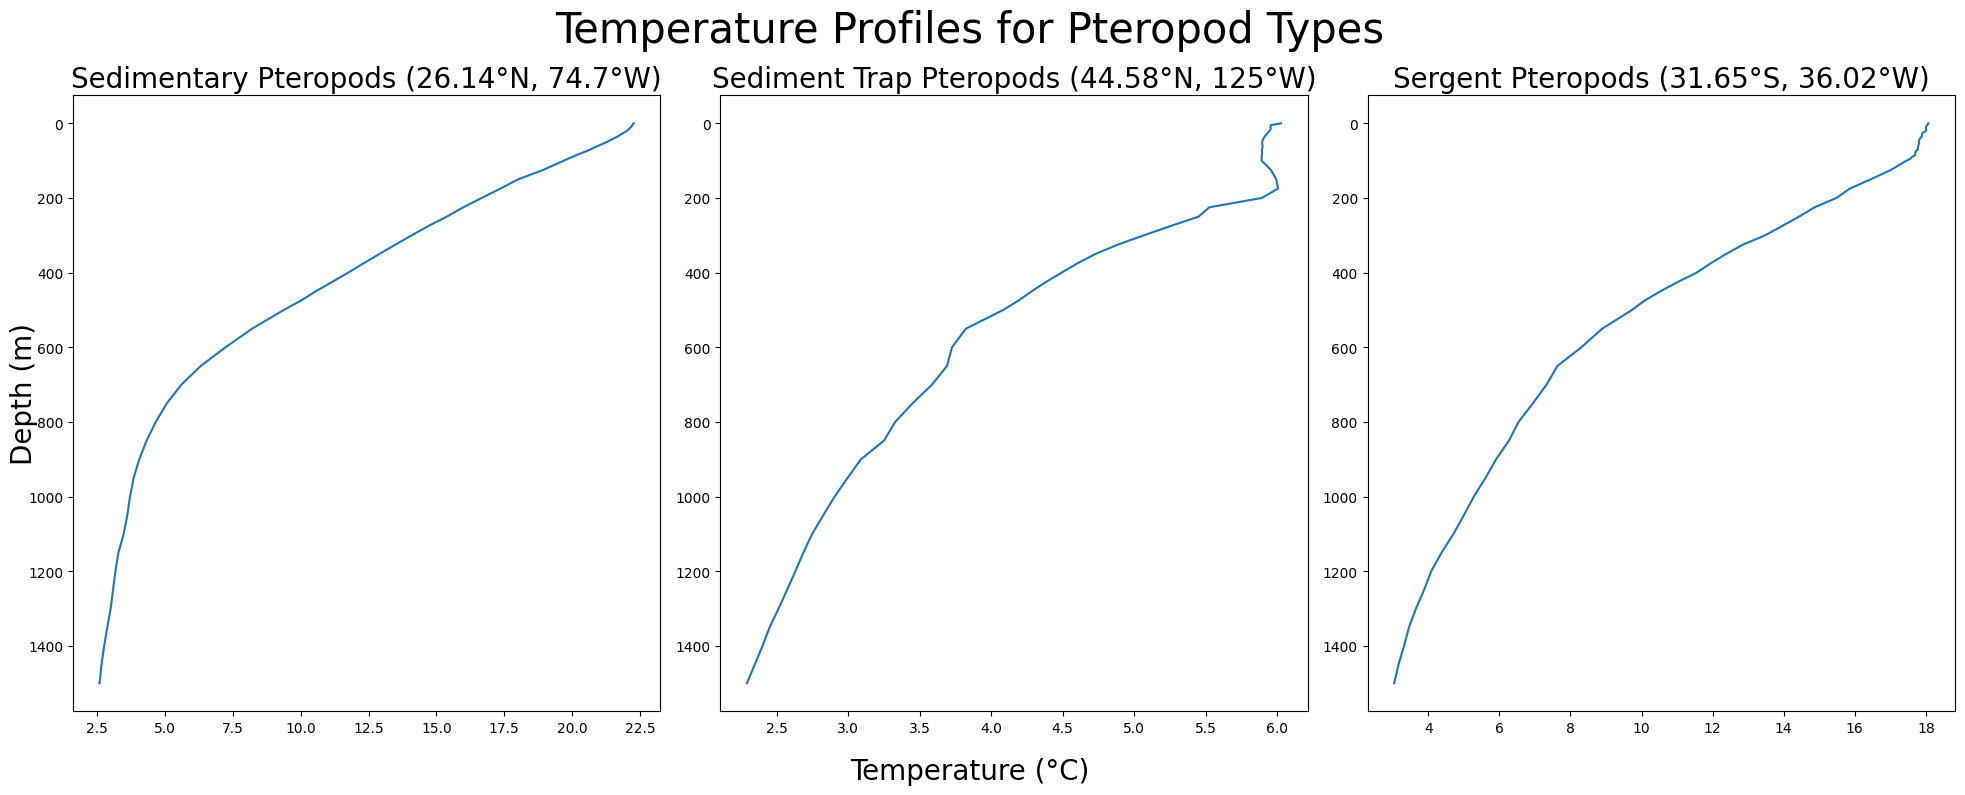

In [14]:
#graph 1: T profiles at all pteropod locations

#select data for correct lat/lons 
#WOA data needs to be in 360 degrees
tsed = t20.sel(lat=26.14, lon=285.3, method='nearest')  
tw = t20.sel(lat=44.583, lon=235, method='nearest')
tser = t80.sel(lat=-31.65, lon=323.98, method='nearest')

#index depths and flatten data
depthsed = tsed['depth']
tsed = tsed.values.flatten()

depthw = tw['depth']
tw = tw.values.flatten()

depthser = tser['depth']
tser = tser.values.flatten()

for d, val in zip(depthsed, tsed):
    print(f"Depth: {d.values} m → Temp: {val:.2f} °C")

fig,axes = plt.subplots(1,3, figsize=(20,8))

axes[0].plot(tsed, depthsed)

axes[1].plot(tw, depthw)

axes[2].plot(tser, depthser)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
axes[2].invert_yaxis()

fig.supxlabel("Temperature (°C)", fontsize =20)
fig.supylabel("Depth (m)", fontsize =20)
fig.suptitle('Temperature Profiles for Pteropod Types', fontsize = 30)

axes[0].set_title("Sedimentary Pteropods (26.14°N, 74.7°W)", fontsize =20)

axes[1].set_title("Sediment Trap Pteropods (44.58°N, 125°W)", fontsize =20)

axes[2].set_title("Sergent Pteropods (31.65°S, 36.02°W)", fontsize =20)

fig.tight_layout()

plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\d'
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_27364/1978976089.py:22: SyntaxWarning: invalid escape sequence '\d'
  fig.supxlabel("$\delta$$^{18}$O (PDB)", fontsize =20)
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_27364/1978976089.py:24: SyntaxWarning: invalid escape sequence '\d'
  fig.suptitle('$\delta$$^{18}$O Profiles for Pteropod Types', fontsize = 30)


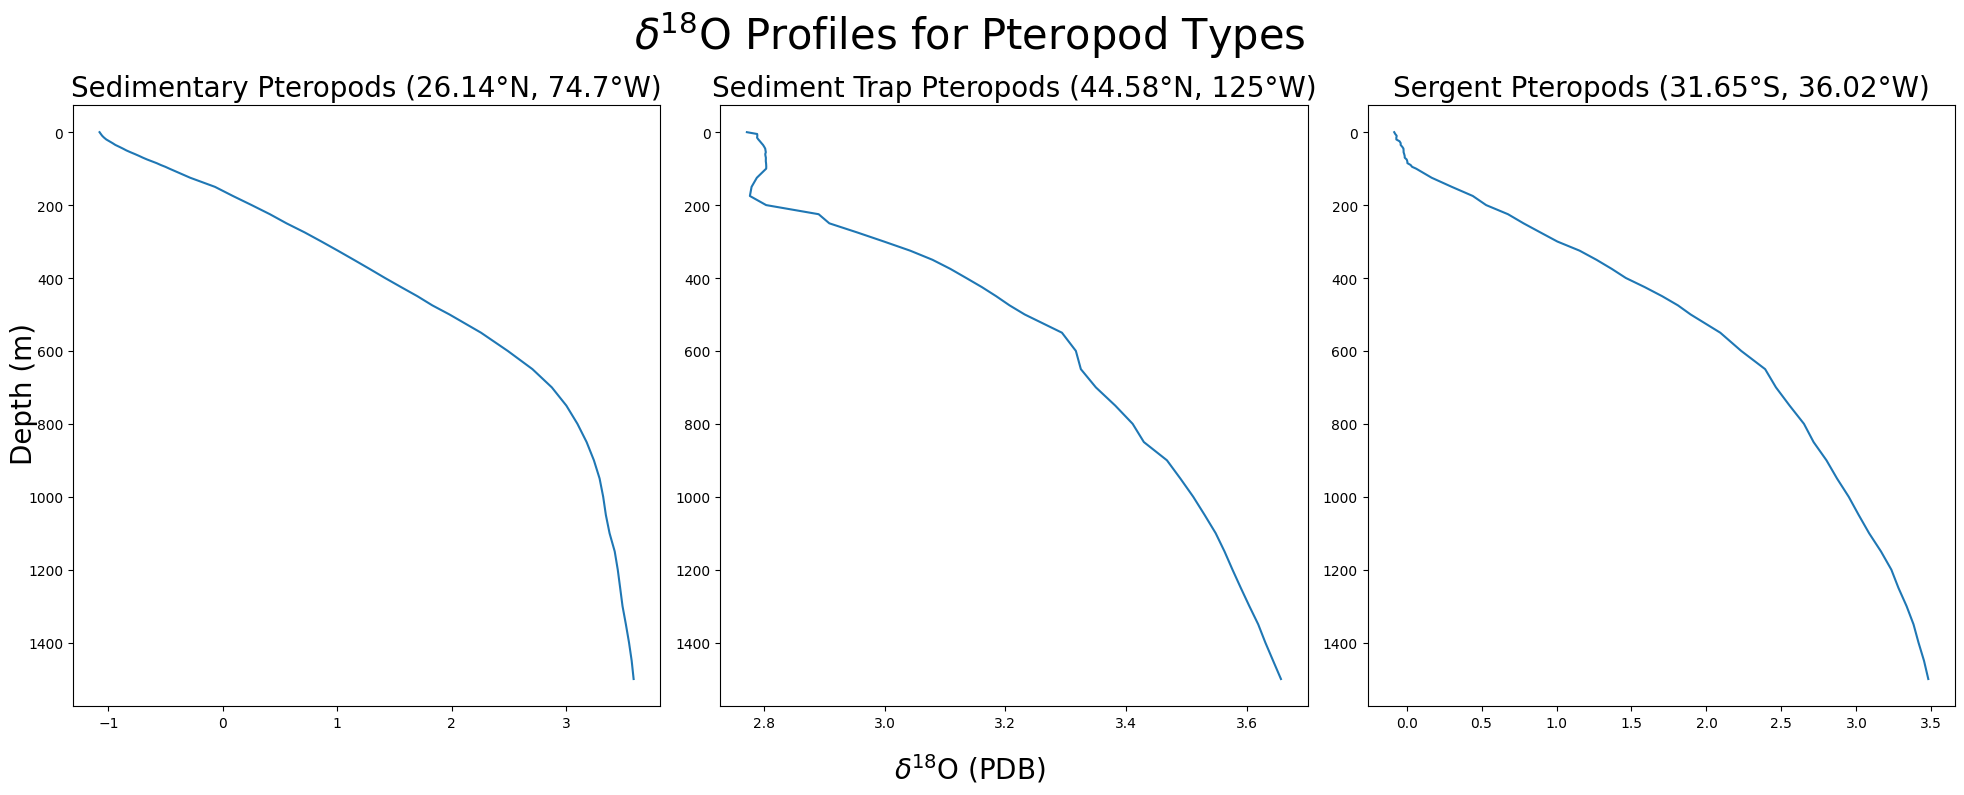

In [16]:
#calculating 18O values 

osed = (tsed*-0.237)+(4.75)+(-0.28-0.27)

oser = (tser*-0.237)+(4.75)+(-0.28-0.27)

ow = (tw*-0.237)+(4.75)+(-0.28-0.27)

#create figure
fig,axes = plt.subplots(1,3, figsize=(20,8))

axes[0].plot(osed, depthsed)

axes[1].plot(ow, depthw)

axes[2].plot(oser, depthser)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
axes[2].invert_yaxis()

fig.supxlabel("$\delta$$^{18}$O (PDB)", fontsize =20)
fig.supylabel("Depth (m)", fontsize =20)
fig.suptitle('$\delta$$^{18}$O Profiles for Pteropod Types', fontsize = 30)

axes[0].set_title("Sedimentary Pteropods (26.14°N, 74.7°W)", fontsize =20)

axes[1].set_title("Sediment Trap Pteropods (44.58°N, 125°W)", fontsize =20)

axes[2].set_title("Sergent Pteropods (31.65°S, 36.02°W)", fontsize =20)

fig.tight_layout()

plt.show()

# for d, val in zip(depthsed, osed):
#     print(f"Depth: {d.values} m → Temp: {val:.2f} °C")

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_27364/3542735492.py:13: SyntaxWarning: invalid escape sequence '\d'
  fig.supxlabel("$\delta$$^{18}$O (PDB)", fontsize =20)
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_27364/3542735492.py:15: SyntaxWarning: invalid escape sequence '\d'
  fig.suptitle('$\delta$$^{18}$O Profiles for Pteropod Types', fontsize = 30)


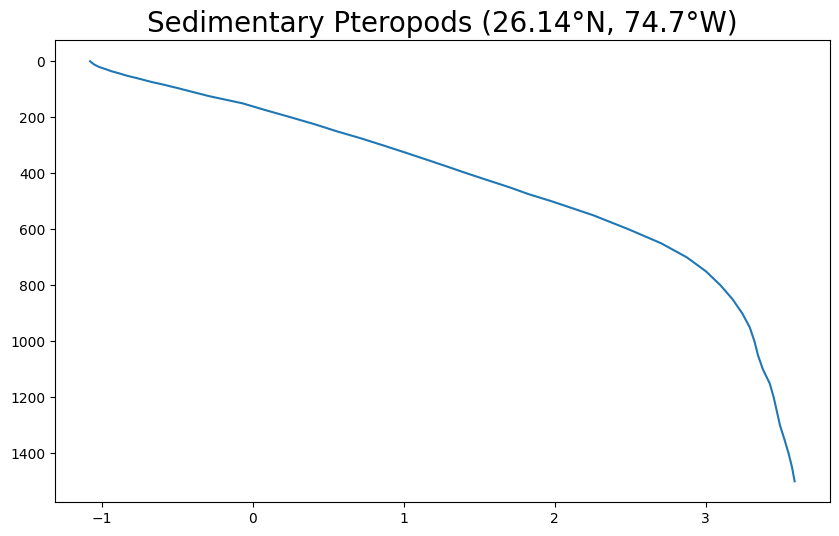

In [18]:
#calculating 18O values 

#create figure
plt.figure(figsize=(10,6))

plt.plot(osed, depthsed)

plt.plot(redsonico, redsonicd)

plt.gca().invert_yaxis()


fig.supxlabel("$\delta$$^{18}$O (PDB)", fontsize =20)
fig.supylabel("Depth (m)", fontsize =20)
fig.suptitle('$\delta$$^{18}$O Profiles for Pteropod Types', fontsize = 30)

plt.title("Sedimentary Pteropods (26.14°N, 74.7°W)", fontsize =20)



fig.tight_layout()

plt.show()


<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_27364/3117284856.py:12: SyntaxWarning: invalid escape sequence '\d'
  fig.supxlabel("$\delta$$^{18}$O (PDB)", fontsize =20)
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_27364/3117284856.py:14: SyntaxWarning: invalid escape sequence '\d'
  fig.suptitle('$\delta$$^{18}$O Profiles for Pteropod Types', fontsize = 30)
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_27364/3117284856.py:12: SyntaxWarning: invalid escape sequence '\d'
  fig.supxlabel("$\delta$$^{18}$O (PDB)", fontsize =20)
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_27364/3117284856.py:14: SyntaxWarning: invalid escape sequence '\d'
  fig.suptitle('$\delta$$^{18}$O Profiles for Pteropod Types', fontsize = 30)


ValueError: x and y must have same first dimension, but have shapes (0,) and (3,)

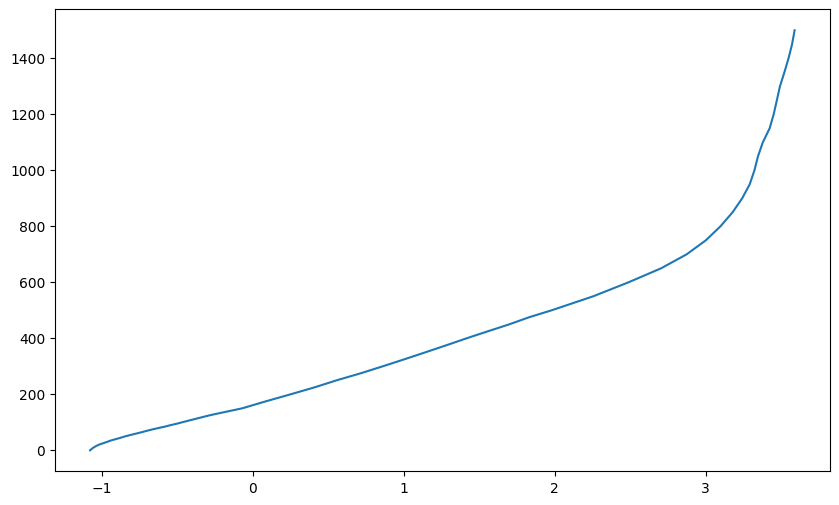

In [20]:
thermocline = [200,200,200]

plt.figure(figsize = (10,6))

plt.plot(osed, depthsed)

plt.plot(redsonico, thermocline)

plt.gca().invert_yaxis()


fig.supxlabel("$\delta$$^{18}$O (PDB)", fontsize =20)
fig.supylabel("Depth (m)", fontsize =20)
fig.suptitle('$\delta$$^{18}$O Profiles for Pteropod Types', fontsize = 30)

plt.title("Sedimentary Pteropods (26.14°N, 74.7°W)", fontsize =20)



fig.tight_layout()

plt.show()


Sedimentary site: steepest slope at 80.0 m (slope = -0.0351 °C/m)
Trap site: steepest slope at 0.0 m (slope = -0.0144 °C/m)
Sergent site: steepest slope at 150.0 m (slope = -0.0232 °C/m)


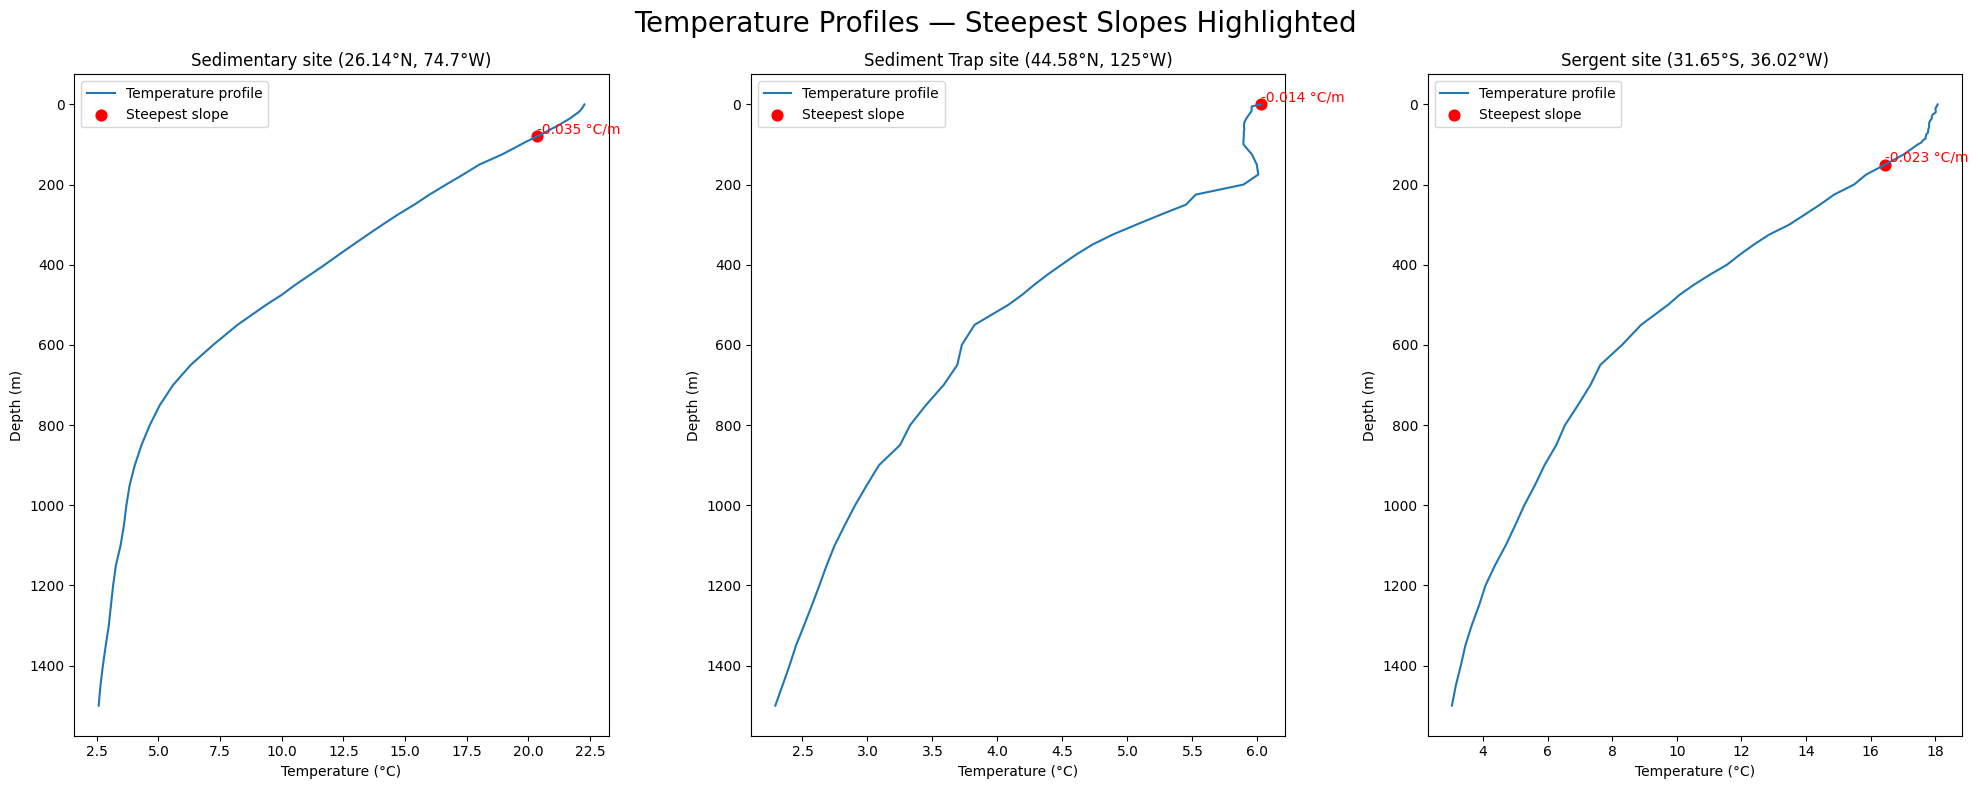

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute temperature gradients (°C per meter) ---
slope_sed = np.gradient(tsed, depthsed)
slope_w = np.gradient(tw, depthw)
slope_ser = np.gradient(tser, depthser)

# --- Find the index of the *steepest* slope (largest |dT/dz|) ---
idx_sed = np.argmax(np.abs(slope_sed))
idx_w = np.argmax(np.abs(slope_w))
idx_ser = np.argmax(np.abs(slope_ser))

# --- Extract corresponding depth, temp, and slope ---
steep_sed = depthsed[idx_sed].values
steep_w = depthw[idx_w].values
steep_ser = depthser[idx_ser].values

print(f"Sedimentary site: steepest slope at {steep_sed} m (slope = {slope_sed[idx_sed]:.4f} °C/m)")
print(f"Trap site: steepest slope at {steep_w} m (slope = {slope_w[idx_w]:.4f} °C/m)")
print(f"Sergent site: steepest slope at {steep_ser} m (slope = {slope_ser[idx_ser]:.4f} °C/m)")

# --- Plot all profiles and highlight steepest slope points ---
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].plot(tsed, depthsed, label='Temperature profile')
axes[1].plot(tw, depthw, label='Temperature profile')
axes[2].plot(tser, depthser, label='Temperature profile')

# Highlight steepest slope points
axes[0].scatter(tsed[idx_sed], depthsed[idx_sed], color='red', s=60, label='Steepest slope')
axes[1].scatter(tw[idx_w], depthw[idx_w], color='red', s=60, label='Steepest slope')
axes[2].scatter(tser[idx_ser], depthser[idx_ser], color='red', s=60, label='Steepest slope')

# Label slope values on the plot
axes[0].text(tsed[idx_sed], depthsed[idx_sed], f"{slope_sed[idx_sed]:.3f} °C/m", color='red', fontsize=10, ha='left', va='bottom')
axes[1].text(tw[idx_w], depthw[idx_w], f"{slope_w[idx_w]:.3f} °C/m", color='red', fontsize=10, ha='left', va='bottom')
axes[2].text(tser[idx_ser], depthser[idx_ser], f"{slope_ser[idx_ser]:.3f} °C/m", color='red', fontsize=10, ha='left', va='bottom')

# Formatting
for ax in axes:
    ax.invert_yaxis()
    ax.legend()
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Depth (m)")

axes[0].set_title("Sedimentary site (26.14°N, 74.7°W)")
axes[1].set_title("Sediment Trap site (44.58°N, 125°W)")
axes[2].set_title("Sergent site (31.65°S, 36.02°W)")

plt.suptitle("Temperature Profiles — Steepest Slopes Highlighted", fontsize=20)
plt.tight_layout()
plt.show()
